In [1]:
import torch
from tqdm.auto import tqdm

from point_e.diffusion.configs import DIFFUSION_CONFIGS, diffusion_from_config
from point_e.diffusion.sampler import PointCloudSampler
from point_e.models.download import load_checkpoint
from point_e.models.configs import MODEL_CONFIGS, model_from_config
from point_e.util.plotting import plot_point_cloud

/home/luddi824/sw/miniconda3/envs/point-E/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('creating base model...')
base_name = 'base40M-textvec'
base_model = model_from_config(MODEL_CONFIGS[base_name], device)
base_model.eval()
base_diffusion = diffusion_from_config(DIFFUSION_CONFIGS[base_name])

print('creating upsample model...')
upsampler_model = model_from_config(MODEL_CONFIGS['upsample'], device)
upsampler_model.eval()
upsampler_diffusion = diffusion_from_config(DIFFUSION_CONFIGS['upsample'])

print('downloading base checkpoint...')
base_model.load_state_dict(load_checkpoint(base_name, device))

print('downloading upsampler checkpoint...')
upsampler_model.load_state_dict(load_checkpoint('upsample', device))

creating base model...


100%|███████████████████████████████████████| 890M/890M [00:37<00:00, 24.9MiB/s]


creating upsample model...
downloading base checkpoint...


100%|██████████| 161M/161M [00:36<00:00, 4.42MiB/s] 


downloading upsampler checkpoint...


100%|██████████| 162M/162M [00:23<00:00, 6.95MiB/s] 


<All keys matched successfully>

In [3]:
sampler = PointCloudSampler(
    device=device,
    models=[base_model, upsampler_model],
    diffusions=[base_diffusion, upsampler_diffusion],
    num_points=[1024, 4096 - 1024],
    aux_channels=['R', 'G', 'B'],
    guidance_scale=[3.0, 0.0],
    model_kwargs_key_filter=('texts', ''), # Do not condition the upsampler at all
)

In [13]:
# Set a prompt to condition on.
prompt = 'an orange car'

# Produce a sample from the model.
samples = None
for x in tqdm(sampler.sample_batch_progressive(batch_size=1, model_kwargs=dict(texts=[prompt]))):
    samples = x

130it [00:50,  2.58it/s]


In [107]:
import numpy as np

# My own visualizations
def scatter_point(x, y, z, ax, col="r", size=0.50):
    # Add a 3D point (x, y, z)
    ax.scatter([x], [y], [z], c=col, marker='o', s=20)
    # Add dotted lines from the point to the respective axes
    ax.plot([x, x], [y, y], [z, -size], col + '--', linewidth=2, alpha=1.0) # to x-axis
    ax.plot([x, x], [y, size], [z, z], col + '--', linewidth=2, alpha=1.0) # to y-axis
    ax.plot([x, -size], [y, y], [z, z], col + '--', linewidth=2, alpha=1.0) # to z-axis
    return ax

def scatter_spheres(x, y, z, ax, col="r", size=0.50):
    ax.scatter([x], [y], [z], c=col, marker='o', s=20)  # Increase the size of the point

    # Add "dotted" lines from the point to the respective axes by creating a series of small spheres along the line
    t = np.linspace(-size, size, num=50)  # Adjust num to add more points along the line
    ax.scatter(np.full_like(t, x), np.full_like(t, y), t, c=col, marker='o', s=3, alpha=1.0)  # to x-axis
    ax.scatter(t, np.full_like(t, y), np.full_like(t, z), c=col, marker='o', s=3, alpha=1.0)  # to y-axis
    ax.scatter(np.full_like(t, x), t, np.full_like(t, z), c=col, marker='o', s=3, alpha=1.0)  # to z-axis
    return ax


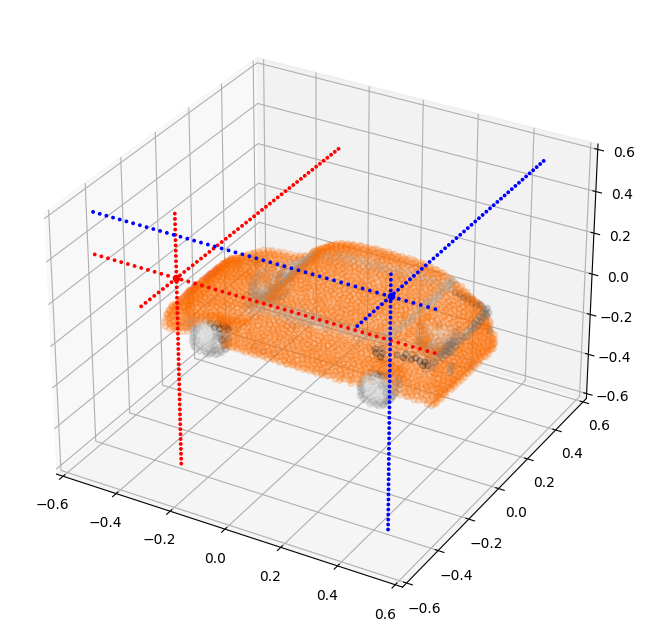

In [113]:
import matplotlib.pyplot as plt
pc = sampler.output_to_point_clouds(samples)[0]
size = 0.60
fig = plot_point_cloud(pc, grid_size=1, fixed_bounds=((-size, -size, -size),(size, size, size)))
# Get the current Axes3D object
ax = plt.gca()
# Reduce the opacity of the point cloud
for c in ax.collections:
    c.set_alpha(0.2)  # Set the alpha to 0.5 or any other value less than 1


# Add dotted lines from the point to the respective axes
ax = scatter_spheres(x=-0.3, y=-0.4, z=0.3, ax=ax, col="r", size=size)
ax = scatter_spheres(x=0.45, y=-0.4, z=0.5, ax=ax, col="b", size=size)
plt.show()